# Preprocessing and Feature Engineering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "COMPETITION_DATA").exists() else Path.cwd().parent
DATA_DIR = REPO_ROOT / "COMPETITION_DATA"
PROCESSED_DIR = REPO_ROOT / "processed_data"
PROCESSED_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)

In [3]:
team_regions = pd.read_csv(DATA_DIR / "Team Region Groups - Sheet1.csv")
data_dict = pd.read_csv(DATA_DIR / "DataDictionary - Sheet1.csv")
regional_games = pd.read_csv(DATA_DIR / "East Regional Games to predict - Sheet1.csv")
games_2022 = pd.read_csv(DATA_DIR / 'games_2022 (edited) - games_2022.csv')
games_2022

,game_id,game_date,team,FGA_2,FGM_2,FGA_3,FGM_3,FTA,FTM,AST,BLK,STL,TOV,TOV_team,DREB,OREB,F_tech,F_personal,team_score,opponent_team_score,largest_lead,OT_length_min_tot,rest_days,attendance,tz_dif_H_E,prev_game_dist,home_away_NS,travel_dist,home_away
0,game_2022_2011,2021-12-30,georgia_lady_bulldogs,50,22,11,5,6,3,14,7,7,18,0,25,11,0,18,62,68,1,0,9,3241.0,0,0,1,0,home
1,game_2022_2011,2021-12-30,lsu_tigers,50,24,11,4,15,8,15,2,15,14,2,25,11,0,7,68,62,14,0,3,3241.0,0,824,-1,824,home
2,game_2022_2012,2021-12-30,missouri_tigers,43,18,15,7,16,13,10,1,4,8,1,31,6,0,11,70,69,8,5,8,6139.0,0,371,1,0,away
3,game_2022_2012,2021-12-30,south_carolina_gamecocks,55,23,21,6,9,5,15,8,3,8,0,27,20,0,15,69,70,6,5,9,6139.0,0,1154,-1,1154,home
4,game_2022_2013,2021-12-30,tennessee_lady_volunteers,41,20,15,4,15,10,16,8,5,15,1,34,12,0,13,62,44,19,0,3,8124.0,0,0,1,0,home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9821,game_2022_4795,2022-03-01,xavier_musketeers,44,19,12,2,12,9,15,3,4,10,0,25,8,0,12,53,74,0,0,2,156.0,0,0,1,0,home
9822,game_2022_4968,2022-03-04,harvard_crimson,30,19,39,15,10,2,20,2,13,6,0,28,10,0,8,85,52,40,0,13,373.0,0,378,-1,173,home
9823,game_2022_4968,2022-03-04,dartmouth_big_green,32,15,26,6,7,4,7,1,4,21,2,29,10,0,8,52,85,3,0,6,373.0,0,479,1,0,home
9824,game_2022_5067,2022-03-06,harvard_crimson,38,13,35,6,10,9,11,3,7,11,0,23,18,0,20,53,73,0,0,2,757.0,0,173,1,0,home


In [4]:
games_2022['team'].nunique()

355

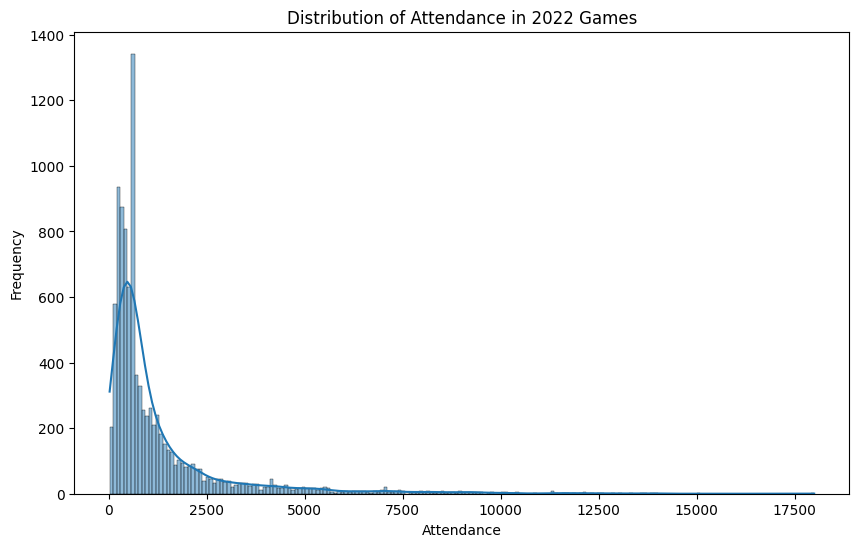

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(games_2022["attendance"], kde=True)
plt.title("Distribution of Attendance in 2022 Games")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.show()

In [7]:
#log normalize

columns_to_transform = [
    'BLK',
    'TOV_team',
    'largest_lead',
    'rest_days',
    'attendance',
    'travel_dist',
    'prev_game_dist'
]

for col in columns_to_transform:
    games_2022[col] = np.log1p(games_2022[col])

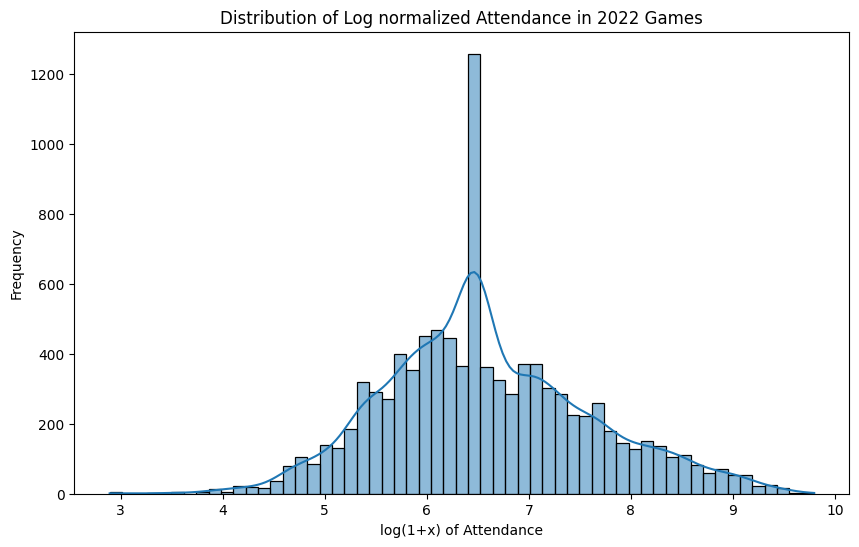

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(games_2022["attendance"], kde=True)
plt.title("Distribution of Log normalized Attendance in 2022 Games")
plt.xlabel("log(1+x) of Attendance")
plt.ylabel("Frequency")
plt.show()

In [9]:
#normalize between 0 and 1

columns_to_normalize = [
    'AST',
    'BLK',
    'STL',
    'TOV',
    'TOV_team',
    'DREB',
    'OREB',
    'F_personal',
    'F_tech',
    'team_score',
    'opponent_team_score',
    'OT_length_min_tot',
    'largest_lead',
    'rest_days',
    'attendance',
    'tz_dif_H_E',
    'prev_game_dist',
    'travel_dist']

scaler = MinMaxScaler(feature_range=(0, 1))
games_2022[columns_to_normalize] = scaler.fit_transform(games_2022[columns_to_normalize])

In [10]:
games_2022["fg_pct_2"] = games_2022["FGM_2"] / games_2022["FGA_2"]
games_2022["fg_pct_3"] = games_2022["FGM_3"] / games_2022["FGA_3"]
games_2022["ft_pct"] = games_2022["FTM"] / games_2022["FTA"]

In [11]:
games_2022["point_diff"] = games_2022["team_score"] - games_2022["opponent_team_score"]

games_2022["win"] = (games_2022["team_score"] > games_2022["opponent_team_score"]).astype(int)

## Save the processed game log

In [ ]:
out_path = PROCESSED_DIR / "games_2022_processed.csv"
games_2022.to_csv(out_path, index=False)
print(f"Saved {games_2022.shape[0]} rows x {games_2022.shape[1]} columns to {out_path}")